
Running with 1 threads...
Time: 0.27 min | CPU: 16.10%

Running with 2 threads...
Time: 0.27 min | CPU: 3.25%

Running with 3 threads...
Time: 0.27 min | CPU: 3.55%

Running with 4 threads...
Time: 0.27 min | CPU: 9.85%

Threads	Time(min)	CPU(%)
1	0.27		16.10
2	0.27		3.25
3	0.27		3.55
4	0.27		9.85


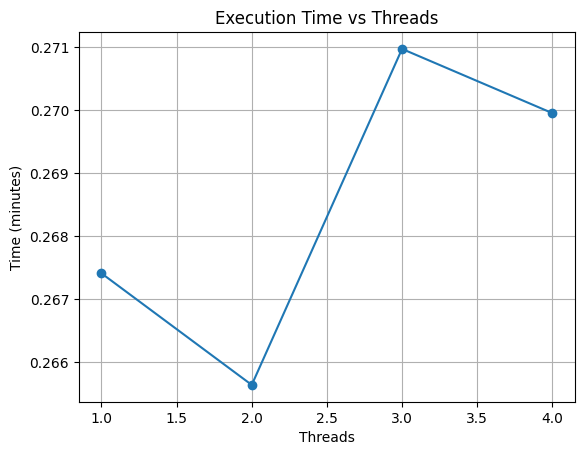

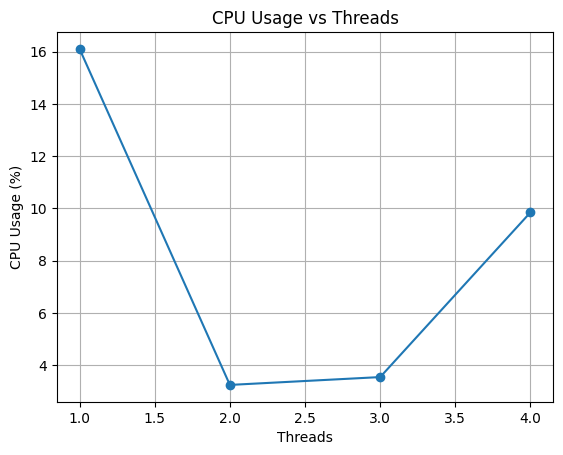

In [1]:
import numpy as np
import time
import multiprocessing as mp
import psutil
import matplotlib.pyplot as plt

# CONFIG
SIZE = 500
NUM_MATRICES = 500
CORES = mp.cpu_count()
THREADS_LIST = list(range(1, 2 * CORES + 1))

# Constant matrix
constant_matrix = np.random.rand(SIZE, SIZE)

# Worker function
def multiply_task(_):
    matrix = np.random.rand(SIZE, SIZE)
    return np.dot(matrix, constant_matrix)

times = []
cpu_usages = []

for threads in THREADS_LIST:
    print(f"\nRunning with {threads} threads...")

    start = time.time()

    # CPU usage before
    cpu_before = psutil.cpu_percent(interval=1)

    with mp.Pool(processes=threads) as pool:
        pool.map(multiply_task, range(NUM_MATRICES))

    # CPU usage after
    cpu_after = psutil.cpu_percent(interval=1)

    end = time.time()

    total_time = (end - start) / 60
    avg_cpu = (cpu_before + cpu_after) / 2

    times.append(total_time)
    cpu_usages.append(avg_cpu)

    print(f"Time: {total_time:.2f} min | CPU: {avg_cpu:.2f}%")

# -----------------------------
# RESULT TABLE
# -----------------------------
print("\nThreads\tTime(min)\tCPU(%)")
for t, tm, cpu in zip(THREADS_LIST, times, cpu_usages):
    print(f"{t}\t{tm:.2f}\t\t{cpu:.2f}")

# -----------------------------
# GRAPH 1: Time
# -----------------------------
plt.figure()
plt.plot(THREADS_LIST, times, marker='o')
plt.xlabel("Threads")
plt.ylabel("Time (minutes)")
plt.title("Execution Time vs Threads")
plt.grid()
plt.show()

# -----------------------------
# GRAPH 2: CPU Usage
# -----------------------------
plt.figure()
plt.plot(THREADS_LIST, cpu_usages, marker='o')
plt.xlabel("Threads")
plt.ylabel("CPU Usage (%)")
plt.title("CPU Usage vs Threads")
plt.grid()
plt.show()